# Foreword

### In this notebook:
- Downloading RPW data from the Solar Orbiter Archive using sunpy Fido
- Plotting the L2 radio spectrogram
- Removing noisy frequencies and plotting again

### Setup
I am using the maser4py library to open the RPW file -- See below how to install maser4py.    
My conda environment is running with:
- Python 3.12.7
- maser-data 0.4.2
- maser-plot 0.3.3
- maser-tools 0.2.0
- maser4py 0.16.1
- sunpy 6.0.3
- sunpy-soar 1.11.1

In [1]:
import sys
print(sys.version)

3.12.7 | packaged by conda-forge | (main, Oct  4 2024, 15:47:54) [MSC v.1941 64 bit (AMD64)]


### History
Last run on May 13 2026 by S. Musset

# Installation (maser4py)

The maser software library is described [here](https://maser.lesia.obspm.fr/task-4-software-library/).     
Installation can be done using pip : [documentation here](https://maser.readthedocs.io/en/latest/sections/1-install.html).    
Some examples on how to use the package are available [here](https://gitlab.obspm.fr/maser/maser4py/-/blob/fix_install/docs/source/sections/tutorial.rst?ref_type=heads).  

# Calls

In [2]:
import matplotlib.pyplot as plt
from sunpy.net import Fido, attrs as a
import sunpy_soar
from maser.data import Data
import numpy as np

# Download data from the SOAR

In [3]:
search_results = Fido.search(
    a.Time("2021-05-22", "2021-05-22"),
    a.Instrument.rpw,
    a.soar.Product('rpw-hfr-surv'),
#    a.soar.Product('rpw-tnr-surv'),
    a.Level(2)
)

print(search_results)

Results from 1 Provider:

1 Results from the SOARClient:

Instrument Data product Level ...         End time        Filesize SOOP Name
                              ...                          Mbyte            
---------- ------------ ----- ... ----------------------- -------- ---------
       RPW rpw-hfr-surv    L2 ... 2021-05-23 00:00:00.000    6.649      none




In [4]:
downloaded_files = Fido.fetch(search_results)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

# Reading file using maser

Read the spectrogram data with a reader from the maser library

In [5]:
hfr_data = Data(downloaded_files[0]).as_xarray()

Converting the voltage power to log scale (will be used to plot)

In [6]:
hfr_power = hfr_data["VOLTAGE_SPECTRAL_POWER"]
hfr_power.values = 10 * np.log10(hfr_power.values)

# Plotting spectrogram

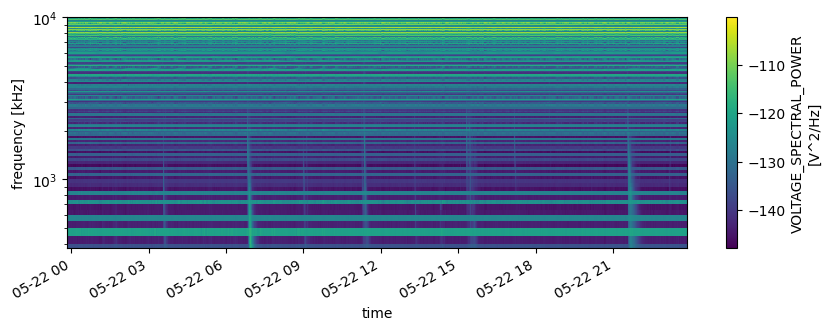

In [7]:
fig = plt.figure(figsize=(10, 3))
hfr_power.plot(yscale="log", ylim=(np.min(hfr_power.frequency.values),10e3))
plt.show()

# Filtering frequencies with interferences

Here is a quick way to get rid of the noisy frequency channels. The idea is to remove them totally from the array of data. The resulting array will be displayed with larger frequency bands (degrading the frequency resolution of the plot).

To decide which frequencies to remove, we simply remove all of those which mean value over the day is above a certain threshold.

In [8]:
freq_to_filter = [hfr_power.frequency.data[i] for i in np.where(hfr_power.mean(dim='time') > -140)[0]]

In [9]:
filtered_hfr_power_v2 = hfr_power.drop_sel({'frequency':freq_to_filter})

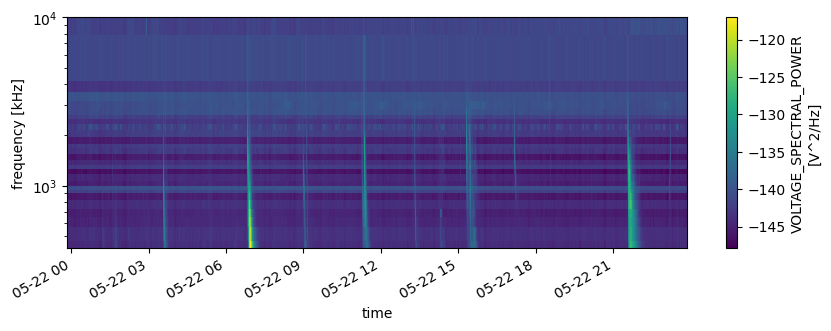

In [10]:
fig = plt.figure(figsize=(10, 3))
filtered_hfr_power_v2.plot(yscale="log", ylim=(np.min(filtered_hfr_power_v2.frequency.values),10e3))
plt.show()